# Entrega biometría

## 1. Curva ROC

Implementar un programa que dado dos ficheros con los scores clientes y scores impostores obtenga:
- Curva ROC
- FP(FN = X ) y umbral
- FN(FP = X ) y umbral
- FP = FN y umbral
- Área bajo la curva ROC
- D-Prime

In [1]:
from pathlib import Path
import sys
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Image, display
import roc_metrics as roc


In [2]:
clients_files = ["scoresA_clientes", "scoresB_clientes"]
impostors_files = ["scoresA_impostores", "scoresB_impostores"]

clients_from_file = roc.read_scores(clients_files[0])
impostors_from_file = roc.read_scores(impostors_files[0])

### Puntos ROC y matriz de confusion por umbral

La función `compute_roc_points` prueba todos los scores como umbrales y añade extremos para cubrir toda la curva.

In [3]:
points = roc.compute_roc_points(clients_from_file, impostors_from_file)
points


,threshold,VP,VN,FP,FN,TPR,S,FPR,FNR,TNR,E
0,-4.940656e-324,1430,0,1560,0,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000
1,0.000000e+00,1430,0,1560,0,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000
2,5.610000e-04,1430,108,1452,0,1.000000,1.000000,0.930769,0.000000,0.069231,0.069231
3,5.680000e-04,1430,109,1451,0,1.000000,1.000000,0.930128,0.000000,0.069872,0.069872
4,5.710000e-04,1430,110,1450,0,1.000000,1.000000,0.929487,0.000000,0.070513,0.070513
...,...,...,...,...,...,...,...,...,...,...,...
2824,9.816890e-01,5,1560,0,1425,0.003497,0.003497,0.000000,0.996503,1.000000,1.000000
2825,9.979550e-01,4,1560,0,1426,0.002797,0.002797,0.000000,0.997203,1.000000,1.000000
2826,9.987200e-01,3,1560,0,1427,0.002098,0.002098,0.000000,0.997902,1.000000,1.000000
2827,1.000000e+00,2,1560,0,1428,0.001399,0.001399,0.000000,0.998601,1.000000,1.000000


### Métricas principales

AUC se calcula comparando cada score de cliente con cada score de impostor. D-Prime usa varianza poblacional.

In [4]:
auc = roc.auc_clientes_impostores(clients_from_file, impostors_from_file)
dprime = roc.d_prime(clients_from_file, impostors_from_file)
eer = roc.approximate_eer(points)

summary = pd.DataFrame([
    {"metrica": "AUC", "valor": auc},
    {"metrica": "D-Prime", "valor": dprime},
    {"metrica": "EER aproximado", "valor": eer["eer"]},
    {"metrica": "Threshold EER", "valor": eer["threshold"]},
    {"metrica": "|FPR - FNR| en EER", "valor": eer["abs_difference"]},
])
summary


,metrica,valor
0,AUC,0.883163
1,D-Prime,0.759954
2,EER aproximado,0.201340
3,Threshold EER,0.050378
4,|FPR - FNR| en EER,0.000117


### FP(FN = X), FN(FP = X) y EER aproximado

In [5]:
fn_x = 0.1
fp_x = 0.05

fp_fn_closest = roc.closest_point(points, "FNR", fn_x)
fp_fn_best = roc.best_with_limit(points, "FNR", fn_x, "FPR")
fn_fp_closest = roc.closest_point(points, "FPR", fp_x)
fn_fp_best = roc.best_with_limit(points, "FPR", fp_x, "FNR")

operating_points = pd.DataFrame([
    {"caso": "FP(FN ~= X): FNR mas cercano", **fp_fn_closest},
    {"caso": "FP(FN <= X): menor FPR", **fp_fn_best},
    {"caso": "FN(FP ~= X): FPR mas cercano", **fn_fp_closest},
    {"caso": "FN(FP <= X): menor FNR", **fn_fp_best},
    {"caso": "EER aproximado", **eer},
])

operating_points[["caso", "threshold", "VP", "VN", "FP", "FN", "FPR", "FNR", "TPR", "TNR"]]


,caso,threshold,VP,VN,FP,FN,FPR,FNR,TPR,TNR
0,FP(FN ~= X): FNR mas cercano,0.031555,1287,931,629,143,0.403205,0.100000,0.900000,0.596795
1,FP(FN <= X): menor FPR,0.031555,1287,931,629,143,0.403205,0.100000,0.900000,0.596795
2,FN(FP ~= X): FPR mas cercano,0.082905,864,1482,78,566,0.050000,0.395804,0.604196,0.950000
3,FN(FP <= X): menor FNR,0.082905,864,1482,78,566,0.050000,0.395804,0.604196,0.950000
4,EER aproximado,0.050378,1142,1246,314,288,0.201282,0.201399,0.798601,0.798718


### Curva ROC

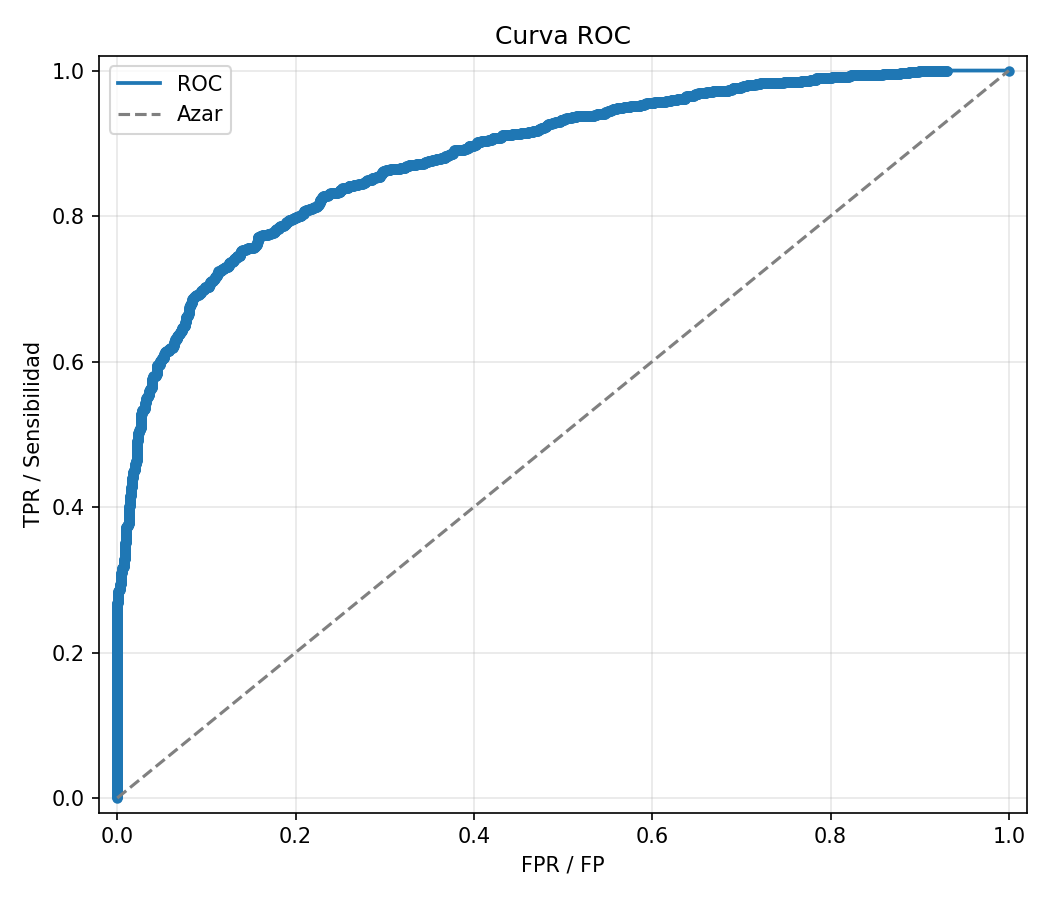

CSV guardado en: resultados_entrega/roc_points_A.csv
Figura guardada en: resultados_entrega/roc_curve_A.png


In [6]:
roc_path = "resultados_entrega/roc_curve_A.png"
csv_path = "resultados_entrega/roc_points_A.csv"

points.to_csv(csv_path, index=False)
roc.plot_roc(points, roc_path)

display(Image(filename=str(roc_path)))
print("CSV guardado en:", csv_path)
print("Figura guardada en:", roc_path)


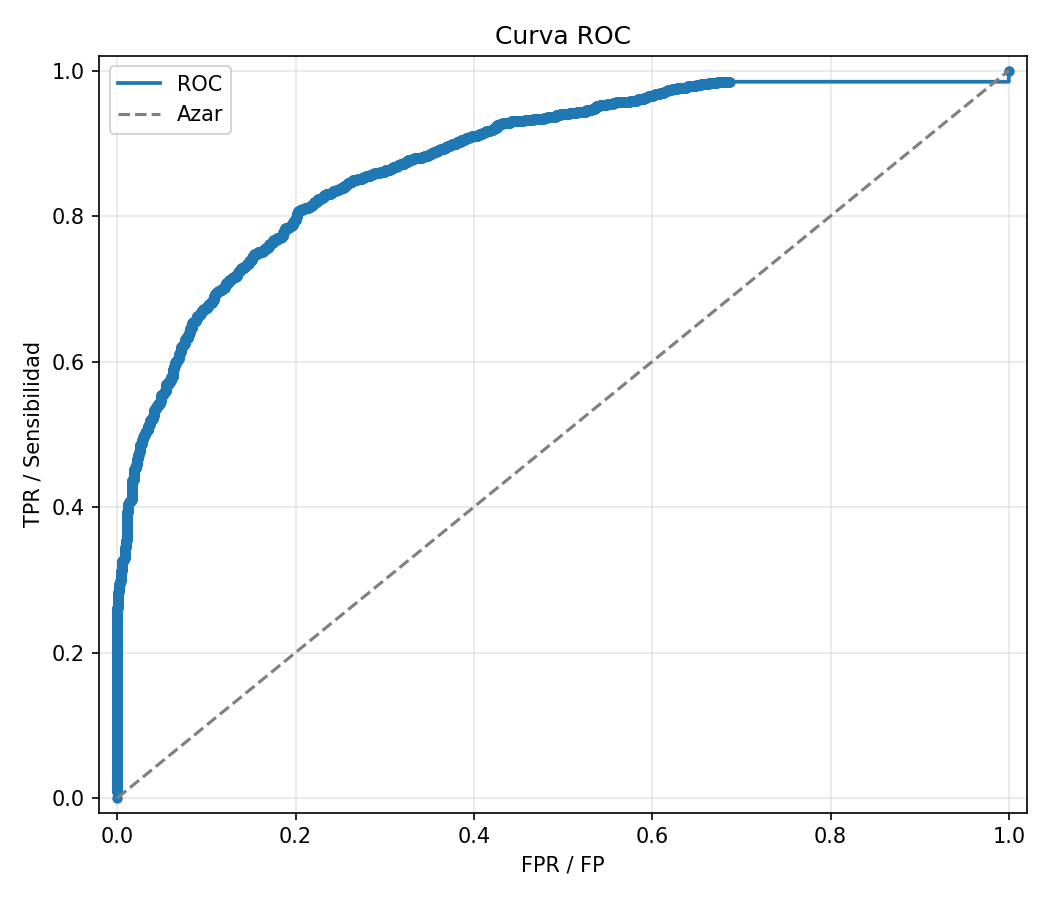

CSV guardado en: resultados_entrega/roc_points_B.csv
Figura guardada en: resultados_entrega/roc_curve_B.png


In [10]:
clients_from_file = roc.read_scores(clients_files[1])
impostors_from_file = roc.read_scores(impostors_files[1])

points = roc.compute_roc_points(clients_from_file, impostors_from_file)
eer = roc.approximate_eer(points)

fn_x = 0.1
fp_x = 0.05

fp_fn_closest = roc.closest_point(points, "FNR", fn_x)
fp_fn_best = roc.best_with_limit(points, "FNR", fn_x, "FPR")
fn_fp_closest = roc.closest_point(points, "FPR", fp_x)
fn_fp_best = roc.best_with_limit(points, "FPR", fp_x, "FNR")

operating_points = pd.DataFrame([
    {"caso": "FP(FN ~= X): FNR mas cercano", **fp_fn_closest},
    {"caso": "FP(FN <= X): menor FPR", **fp_fn_best},
    {"caso": "FN(FP ~= X): FPR mas cercano", **fn_fp_closest},
    {"caso": "FN(FP <= X): menor FNR", **fn_fp_best},
    {"caso": "EER aproximado", **eer},
])

auc = roc.auc_clientes_impostores(clients_from_file, impostors_from_file)
dprime = roc.d_prime(clients_from_file, impostors_from_file)
eer = roc.approximate_eer(points)

summary = pd.DataFrame([
    {"metrica": "AUC", "valor": auc},
    {"metrica": "D-Prime", "valor": dprime},
    {"metrica": "EER aproximado", "valor": eer["eer"]},
    {"metrica": "Threshold EER", "valor": eer["threshold"]},
    {"metrica": "|FPR - FNR| en EER", "valor": eer["abs_difference"]},
])

roc_path = "resultados_entrega/roc_curve_B.png"
csv_path = "resultados_entrega/roc_points_B.csv"

points.to_csv(csv_path, index=False)
roc.plot_roc(points, roc_path)

display(Image(filename=str(roc_path)))
print("CSV guardado en:", csv_path)
print("Figura guardada en:", roc_path)

In [11]:
summary

,metrica,valor
0,AUC,0.883083
1,D-Prime,0.873482
2,EER aproximado,0.200991
3,Threshold EER,0.044444
4,|FPR - FNR| en EER,0.000583


In [12]:
operating_points

,caso,threshold,VP,VN,FP,FN,TPR,S,FPR,FNR,TNR,E,abs_difference,eer
0,FP(FN ~= X): FNR mas cercano,0.014806,1287,967,593,143,0.900000,0.900000,0.380128,0.100000,0.619872,0.619872,NaN,NaN
1,FP(FN <= X): menor FPR,0.014806,1287,967,593,143,0.900000,0.900000,0.380128,0.100000,0.619872,0.619872,NaN,NaN
2,FN(FP ~= X): FPR mas cercano,0.145029,793,1482,78,637,0.554545,0.554545,0.050000,0.445455,0.950000,0.950000,NaN,NaN
3,FN(FP <= X): menor FNR,0.145029,793,1482,78,637,0.554545,0.554545,0.050000,0.445455,0.950000,0.950000,NaN,NaN
4,EER aproximado,0.044444,1143,1246,314,287,0.799301,0.799301,0.201282,0.200699,0.798718,0.798718,0.000583,0.200991


### Interpretación de los resultados ROC

Las dos curvas ROC quedan claramente por encima de la diagonal de azar, por lo que los scores permiten separar clientes e impostores mejor que una decisión aleatoria. El AUC es muy parecido en ambos ficheros, alrededor de 0.883, lo que indica que la capacidad global de ordenación de clientes frente a impostores es prácticamente la misma.

En el punto de equilibrio, el EER queda alrededor del 20% en ambos casos. Esto significa que, si se elige el umbral donde FPR y FNR son aproximadamente iguales, el sistema acepta por error a unos impostores en la misma proporción en la que rechaza por error a clientes. Aunque el D-Prime es mayor en el caso B, el EER apenas cambia, así que esa mayor separación estadística no se traduce en una mejora clara en el punto operativo de igual error.

También se observa el compromiso típico de verificación biométrica. Si se fuerza una tasa baja de falsos negativos, FN = 10%, la tasa de falsos positivos queda alta. En cambio, si se fuerza FP = 5%, aumentan mucho los falsos negativos. Por tanto, el umbral no se debe escoger sólo por el EER, sino según la aplicación: si se prioriza seguridad conviene reducir FP, y si se prioriza comodidad de uso conviene reducir FN.

## 2. Normalization and equalization

- Implementar normalización y ecualización locales
- Utilizar imagen integral, media y varianza para normalización
- Utilizar posibles mejoras para ecualización local
- Se valorará la implementación correctamente parametrizada, velocidad, ocupación memoria, etc...

In [14]:
from pathlib import Path
import importlib
import os
import sys
os.environ.setdefault("MPLCONFIGDIR", "/tmp/matplotlib")
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

if (Path.cwd() / "biometria" / "local_light.py").exists():
    sys.path.insert(0, str((Path.cwd() / "biometria").resolve()))
    YALEB_DIR = Path.cwd() / "biometria" / "ILLUMINATION" / "YaleB"
    LIGHT_OUT = Path.cwd() / "biometria" / "outputs" / "local_light_yaleb"
else:
    YALEB_DIR = Path("ILLUMINATION") / "YaleB"
    LIGHT_OUT = Path("outputs") / "local_light_yaleb"

import local_light as light
importlib.reload(light)

LIGHT_OUT.mkdir(parents=True, exist_ok=True)
yaleb_images = light.imagenes_yaleb(YALEB_DIR)
sample_paths = [p for p in yaleb_images if p.parent.name == "yaleB02"][:3]

print(f"Imagenes YaleB unicas: {len(yaleb_images)}")
print("Muestras usadas:")
for path in sample_paths:
    print(" -", path.relative_to(YALEB_DIR))

Imagenes YaleB unicas: 2387
Muestras usadas:
 - yaleB02/yaleB02_P00A+000E+00.pgm
 - yaleB02/yaleB02_P00A+000E+20.pgm
 - yaleB02/yaleB02_P00A+000E+45.pgm


### Prueba visual sobre YaleB

Se toma una cara de YaleB con iluminación controlada y se aplican los cuatro meŕodos implementados. Las versiones locales usan ventana y paso configurables.

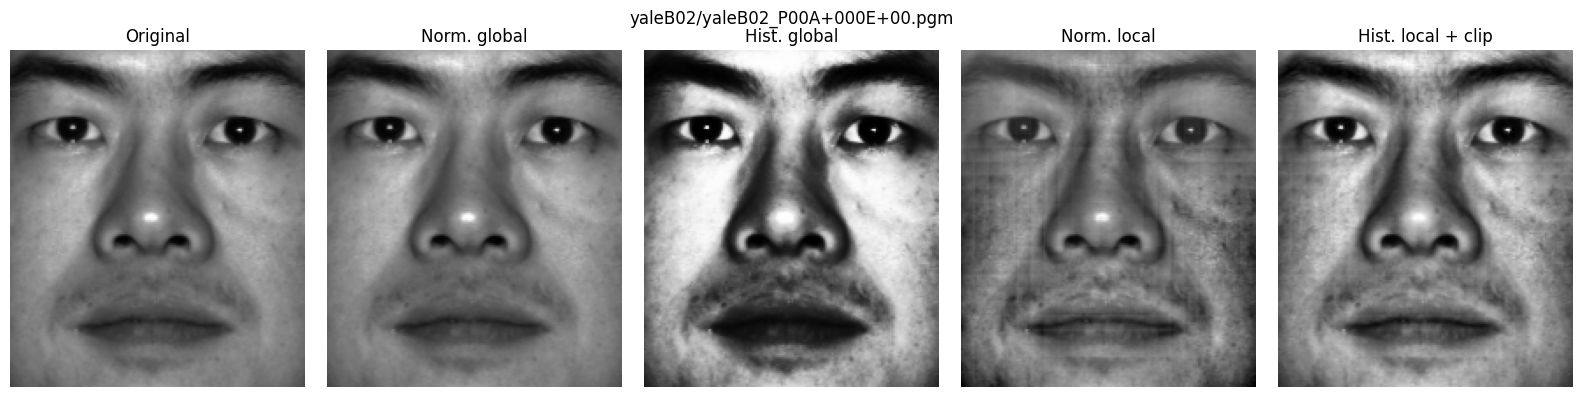

In [15]:
sample = sample_paths[0]
image = light.leer_gris(sample)
window_size = 31
stride = 8
clip_limit = 1.5

processed = {
    "Original": image,
    "Norm. global": light.norm_global(image),
    "Hist. global": light.hist_global(image),
    "Norm. local": light.norm_local(image, lado=window_size, paso=stride),
    "Hist. local + clip": light.hist_local(image, lado=window_size, paso=stride, clip=clip_limit),
}

fig, axes = plt.subplots(1, len(processed), figsize=(16, 4))
for ax, (title, img) in zip(axes, processed.items()):
    ax.imshow(light.a_uint8(img), cmap="gray", vmin=0, vmax=255)
    ax.set_title(title)
    ax.axis("off")
fig.suptitle(sample.relative_to(YALEB_DIR).as_posix())
fig.tight_layout()

### Comprobación de la imagen integral

Para probar que la normalización local usa correctamente media y varianza locales, se compara el resultado obtenido con imagen integral frente al cálculo directo sobre la misma ventana.

In [16]:
y, x = image.shape[0] // 2, image.shape[1] // 2
r = window_size // 2
y0, y1 = max(0, y - r), min(image.shape[0], y + r + 1)
x0, x1 = max(0, x - r), min(image.shape[1], x + r + 1)
patch = image[y0:y1, x0:x1]

media, varianza = light.media_var_local(image, window_size)
manual_mean = float(patch.mean())
manual_var = float(patch.var())

check_integral = pd.DataFrame(
    [
        ["media local", manual_mean, float(media[y, x]), abs(manual_mean - float(media[y, x]))],
        ["varianza local", manual_var, float(varianza[y, x]), abs(manual_var - float(varianza[y, x]))],
    ],
    columns=["magnitud", "calculo directo", "imagen integral", "error absoluto"],
)

assert check_integral["error absoluto"].max() < 1e-3
check_integral

,magnitud,calculo directo,imagen integral,error absoluto
0,media local,116.525497,116.525497,0.000000
1,varianza local,1640.467773,1640.467896,0.000122


La comprobación de la imagen integral confirma que la media y la varianza locales se están calculando correctamente: el resultado coincide con el cálculo directo sobre la ventana, con un error numérico prácticamente nulo. Esto es importante porque la normalización local depende de estimar bien la iluminación media y la variabilidad de cada zona de la imagen.

### Ejecución parametrizada y tiempos

In [17]:
rows = light.procesar_carpeta(
    entrada=YALEB_DIR,
    carpeta_salida=LIGHT_OUT,
    metodo="all",
    lado=window_size,
    paso=stride,
    clip=clip_limit,
    guardar_comparativa=True,
    limite=3,
)

light_df = pd.DataFrame(rows)
time_summary = (
    light_df.groupby("metodo", as_index=False)
    .agg(imagenes=("imagen", "count"), tiempo_medio_s=("segundos", "mean"), tiempo_total_s=("segundos", "sum"))
)
time_summary["tiempo_medio_s"] = time_summary["tiempo_medio_s"].round(4)
time_summary["tiempo_total_s"] = time_summary["tiempo_total_s"].round(4)

display(time_summary)
display(light_df[["imagen", "metodo", "lado", "paso", "segundos", "salida"]].head(8))

,metodo,imagenes,tiempo_medio_s,tiempo_total_s
0,hist_global,3,0.0002,0.0006
1,hist_local,3,0.0071,0.0213
2,norm_global,3,0.0001,0.0004
3,norm_local,3,0.0034,0.0103


,imagen,metodo,lado,paso,segundos,salida
0,ILLUMINATION/YaleB/yaleB02/yaleB02_P00A+000E+0...,norm_global,31,8,0.000134,outputs/local_light_yaleb/yaleB02/yaleB02_P00A...
1,ILLUMINATION/YaleB/yaleB02/yaleB02_P00A+000E+0...,hist_global,31,8,0.000252,outputs/local_light_yaleb/yaleB02/yaleB02_P00A...
2,ILLUMINATION/YaleB/yaleB02/yaleB02_P00A+000E+0...,norm_local,31,8,0.003326,outputs/local_light_yaleb/yaleB02/yaleB02_P00A...
3,ILLUMINATION/YaleB/yaleB02/yaleB02_P00A+000E+0...,hist_local,31,8,0.007049,outputs/local_light_yaleb/yaleB02/yaleB02_P00A...
4,ILLUMINATION/YaleB/yaleB02/yaleB02_P00A+000E+2...,norm_global,31,8,0.000104,outputs/local_light_yaleb/yaleB02/yaleB02_P00A...
5,ILLUMINATION/YaleB/yaleB02/yaleB02_P00A+000E+2...,hist_global,31,8,0.000128,outputs/local_light_yaleb/yaleB02/yaleB02_P00A...
6,ILLUMINATION/YaleB/yaleB02/yaleB02_P00A+000E+2...,norm_local,31,8,0.003661,outputs/local_light_yaleb/yaleB02/yaleB02_P00A...
7,ILLUMINATION/YaleB/yaleB02/yaleB02_P00A+000E+2...,hist_local,31,8,0.007616,outputs/local_light_yaleb/yaleB02/yaleB02_P00A...


Los métodos globales son más rápidos porque aplican una única transformación a toda la imagen. En cambio, los métodos locales tienen más coste porque calculan estadísticas o histogramas por regiones. Aun así, los tiempos obtenidos son bajos: la normalización local tarda más que la global, pero sigue siendo rápida; la ecualización local es la más costosa porque debe redistribuir el histograma localmente.

### Clipping en la ecualización local

La ecualización local incluye un límite tipo CLAHE. La comparación muestra que el parámetro `clip_limit` modifica la salida y permite suavizar la redistribución del histograma local.

,version,std,p95-p5,niveles_usados,dif_media_abs
0,hist_local sin clipping,66.644918,213.0,256,0.000000
1,hist_local clip=1.5,48.116418,162.0,256,23.041481


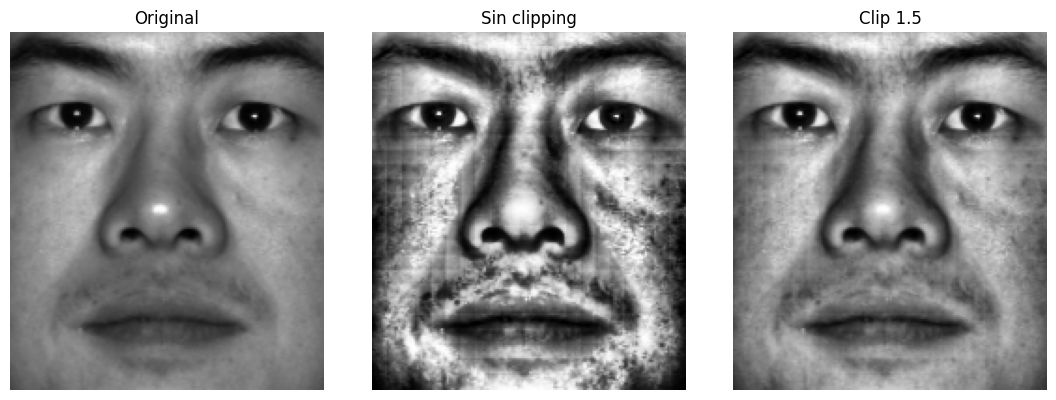

In [18]:
hist_sin_clip = light.hist_local(image, lado=window_size, paso=stride, clip=None)
hist_con_clip = light.hist_local(image, lado=window_size, paso=stride, clip=clip_limit)

def resumen_img(nombre, img, referencia=None):
    img_u8 = light.a_uint8(img)
    fila = {
        "version": nombre,
        "std": float(img_u8.std()),
        "p95-p5": float(np.percentile(img_u8, 95) - np.percentile(img_u8, 5)),
        "niveles_usados": int(np.unique(img_u8).size),
    }
    if referencia is not None:
        fila["dif_media_abs"] = float(np.mean(np.abs(img_u8.astype(np.float32) - referencia.astype(np.float32))))
    else:
        fila["dif_media_abs"] = 0.0
    return fila

ref = light.a_uint8(hist_sin_clip)
clip_summary = pd.DataFrame([
    resumen_img("hist_local sin clipping", hist_sin_clip),
    resumen_img(f"hist_local clip={clip_limit}", hist_con_clip, ref),
])

fig, axes = plt.subplots(1, 3, figsize=(11, 4))
axes[0].imshow(light.a_uint8(image), cmap="gray", vmin=0, vmax=255)
axes[0].set_title("Original")
axes[1].imshow(light.a_uint8(hist_sin_clip), cmap="gray", vmin=0, vmax=255)
axes[1].set_title("Sin clipping")
axes[2].imshow(light.a_uint8(hist_con_clip), cmap="gray", vmin=0, vmax=255)
axes[2].set_title(f"Clip {clip_limit}")
for ax in axes:
    ax.axis("off")
fig.tight_layout()

clip_summary

El clipping en la ecualización local actúa como una mejora tipo CLAHE. Sin clipping, el contraste local aumenta mucho y pueden aparecer zonas demasiado marcadas. Con `clip=1.5`, la desviación típica baja de 66.64 a 48.12 y el rango `p95-p5` baja de 213 a 162, por lo que la imagen queda menos agresiva y más estable. La diferencia media absoluta entre ambas versiones muestra que el parámetro modifica realmente la salida, no es un cambio superficial.

## Eigenfaces

- Implementar eigenfaces
- Probar con ORL:
    - Training: imágenes [1 − 5] de cada individuo
    - Test: imágenes [6 − 10] de cada individuo
- Utilizar el vecino más cercano
- Obtener curvas de error variando dSe valorará haber tenido en cuenta las consideraciones prácticas


### Preparación de ORL


In [5]:
from pathlib import Path
import importlib
import os
import sys

os.environ.setdefault("MPLCONFIGDIR", "/tmp/matplotlib")
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
try:
    from IPython.display import display
except ImportError:
    def display(obj):
        print(obj)

if (Path.cwd() / "biometria" / "eigenfaces_orl.py").exists():
    BASE_DIR = Path.cwd() / "biometria"
else:
    BASE_DIR = Path.cwd()

if str(BASE_DIR.resolve()) not in sys.path:
    sys.path.insert(0, str(BASE_DIR.resolve()))

import eigenfaces_orl as eigen
importlib.reload(eigen)

ORL_DIR = BASE_DIR / "ORLProcessed"
TRAIN_DIR = ORL_DIR / "Train"
TEST_DIR = ORL_DIR / "Test"
EIGEN_OUT = BASE_DIR / "outputs" / "eigenfaces_orl"
EIGEN_OUT.mkdir(parents=True, exist_ok=True)

print("Directorio ORL:", ORL_DIR)


Directorio ORL: /home/odra/GitHub/ComputerVisionLab/biometria/ORLProcessed


In [6]:
train_samples, y_train = eigen.load_orl_dataset(TRAIN_DIR)
test_samples, y_test = eigen.load_orl_dataset(TEST_DIR)

assert sorted({s.image_number for s in train_samples}) == [1, 2, 3, 4, 5]
assert sorted({s.image_number for s in test_samples}) == [6, 7, 8, 9, 10]

X_train = eigen.vectorize_images(train_samples)
X_test = eigen.vectorize_images(test_samples)
image_shape = train_samples[0].image.shape

split_df = pd.DataFrame(
    [
        {"persona": sample.label, "imagen": sample.image_number, "split": "train", "ruta": sample.path.relative_to(ORL_DIR).as_posix()}
        for sample in train_samples
    ]
    + [
        {"persona": sample.label, "imagen": sample.image_number, "split": "test", "ruta": sample.path.relative_to(ORL_DIR).as_posix()}
        for sample in test_samples
    ]
)

resumen_split = (
    split_df.groupby("split", as_index=False)
    .agg(personas=("persona", "nunique"), imagenes=("ruta", "count"))
)

print(f"Tamano imagen: {image_shape[1]}x{image_shape[0]} px")
display(resumen_split)
display(split_df.head(10))


Tamano imagen: 92x112 px


,split,personas,imagenes
0,test,40,200
1,train,40,200


,persona,imagen,split,ruta
0,1,1,train,Train/s1/1.pgm
1,1,2,train,Train/s1/2.pgm
2,1,3,train,Train/s1/3.pgm
3,1,4,train,Train/s1/4.pgm
4,1,5,train,Train/s1/5.pgm
5,2,1,train,Train/s2/1.pgm
6,2,2,train,Train/s2/2.pgm
7,2,3,train,Train/s2/3.pgm
8,2,4,train,Train/s2/4.pgm
9,2,5,train,Train/s2/5.pgm



### PCA y vecino más cercano

La matriz de píxeles es grande, así que calculo las eigenfaces con la matriz pequeña de entrenamiento. Después proyecto train y test en el subespacio PCA y clasifico cada imagen de test con vecino más cercano euclídeo.


In [7]:
mean_face, eigenvectors, eigvals = eigen.fit_eigenfaces(X_train)
max_dim = eigenvectors.shape[1]
dims = [1, 2, 3, 5, 10, 15, 20, 30, 40, 60, 80, 100, 150]
dims = [d for d in dims if d <= max_dim]

resultados, pred_rows = eigen.evaluate_for_dimensions(
    X_train=X_train,
    y_train=y_train,
    X_test=X_test,
    y_test=y_test,
    mean_face=mean_face,
    eigenvectors=eigenvectors,
    dims=dims,
    test_paths=[sample.path.relative_to(ORL_DIR).as_posix() for sample in test_samples],
)

results_df = pd.DataFrame(resultados).rename(columns={"k": "d", "error_rate": "tasa_error", "num_errors": "errores"})
pred_df = pd.DataFrame(pred_rows).rename(
    columns={
        "k": "d",
        "test_path": "imagen",
        "true_label": "persona_real",
        "predicted_label": "persona_predicha",
        "correct": "correcta",
    }
)

best_row = results_df.loc[results_df["accuracy"].idxmax()]
best_k = int(best_row["d"])

results_df.to_csv(EIGEN_OUT / "resultados_orl.csv", index=False)
pred_df.to_csv(EIGEN_OUT / "predicciones_orl.csv", index=False)

print(f"Eigenfaces disponibles: {max_dim}")
print(f"Mejor d: {best_k} | accuracy={best_row['accuracy']:.3f} | error={best_row['tasa_error']:.3f}")
results_df


Eigenfaces disponibles: 199
Mejor d: 80 | accuracy=0.895 | error=0.105


,d,accuracy,tasa_error,errores,num_test
0,1,0.115,0.885,177,200
1,2,0.320,0.680,136,200
2,3,0.550,0.450,90,200
3,5,0.700,0.300,60,200
4,10,0.840,0.160,32,200
5,15,0.835,0.165,33,200
6,20,0.855,0.145,29,200
7,30,0.875,0.125,25,200
8,40,0.885,0.115,23,200
9,60,0.890,0.110,22,200



### Curva de error


PosixPath('/home/odra/GitHub/ComputerVisionLab/biometria/outputs/eigenfaces_orl/curva_error_orl.png')

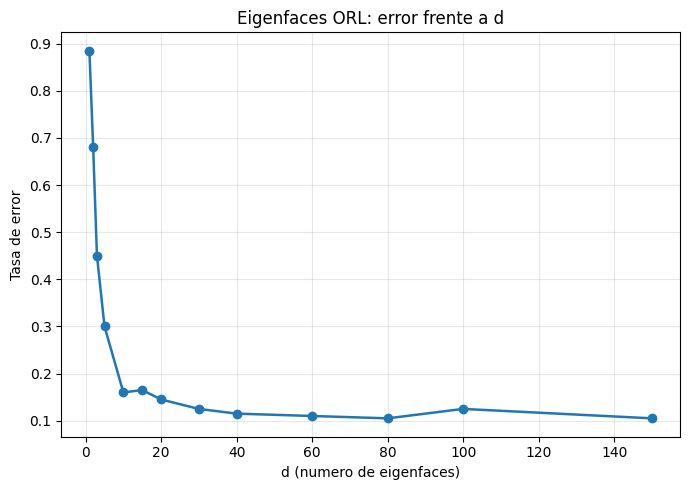

In [8]:
fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(results_df["d"], results_df["tasa_error"], marker="o", linewidth=1.8)
ax.set_xlabel("d (numero de eigenfaces)")
ax.set_ylabel("Tasa de error")
ax.set_title("Eigenfaces ORL: error frente a d")
ax.grid(True, alpha=0.3)
fig.tight_layout()

curve_path = EIGEN_OUT / "curva_error_orl.png"
fig.savefig(curve_path, dpi=150)
curve_path


La curva de error muestra que con muy pocas eigenfaces se pierde demasiada información. Con `d=1` el error es 0.885, porque una sola componente no puede representar bien las diferencias entre personas. Al aumentar `d`, el error baja rápidamente: con `d=10` ya se obtiene un error de 0.160. El mejor resultado aparece con `d=80` y también con `d=150`, con una accuracy de 0.895 y un error de 0.105.

A partir de cierto número de componentes la mejora se estabiliza. Esto tiene sentido porque las primeras eigenfaces recogen la variación principal de las caras, pero las componentes posteriores pueden contener detalles menos útiles para reconocer identidad, como iluminación, gesto o ruido. Por eso aumentar `d` no garantiza siempre mejorar la clasificación.


### Cara media y primeras eigenfaces


(PosixPath('/home/odra/GitHub/ComputerVisionLab/biometria/outputs/eigenfaces_orl/cara_media.png'),
 PosixPath('/home/odra/GitHub/ComputerVisionLab/biometria/outputs/eigenfaces_orl/primeras_eigenfaces.png'))

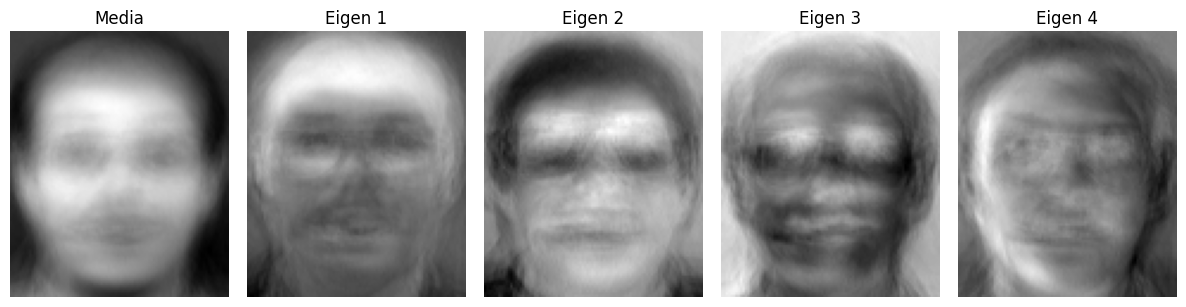

In [9]:
mean_path = EIGEN_OUT / "cara_media.png"
eigen_grid_path = EIGEN_OUT / "primeras_eigenfaces.png"
eigen.save_mean_face(mean_face, image_shape, mean_path)
eigen.save_eigenfaces_grid(eigenvectors, image_shape, eigen_grid_path, num_faces=16)

fig, axes = plt.subplots(1, 5, figsize=(12, 3))
axes[0].imshow(eigen.to_uint8_visualization(mean_face.reshape(image_shape)), cmap="gray", vmin=0, vmax=255)
axes[0].set_title("Media")
for i, ax in enumerate(axes[1:], start=1):
    ax.imshow(eigen.to_uint8_visualization(eigenvectors[:, i - 1].reshape(image_shape)), cmap="gray", vmin=0, vmax=255)
    ax.set_title(f"Eigen {i}")
for ax in axes:
    ax.axis("off")
fig.tight_layout()

mean_path, eigen_grid_path



### Errores con la mejor dimensión

Con la mejor dimensión de la curva, miro qué imágenes fallan. Esto sirve para comprobar si los errores se explican por gestos, gafas o cambios de iluminación concretos.


In [10]:
pred_best = pred_df[pred_df["d"] == best_k].copy()

por_persona = (
    pred_best.groupby("persona_real", as_index=False)
    .agg(test=("correcta", "count"), accuracy=("correcta", "mean"), errores=("correcta", lambda s: int((~s).sum())))
    .sort_values(["accuracy", "errores"], ascending=[True, False])
)
por_persona["accuracy"] = por_persona["accuracy"].round(3)

display(por_persona.head(10))
display(pred_best.loc[~pred_best["correcta"], ["imagen", "persona_real", "persona_predicha", "distance"]].head(10))


,persona_real,test,accuracy,errores
16,17,5,0.4,3
26,27,5,0.4,3
35,36,5,0.6,2
4,5,5,0.8,1
8,9,5,0.8,1
9,10,5,0.8,1
10,11,5,0.8,1
13,14,5,0.8,1
18,19,5,0.8,1
19,20,5,0.8,1


,imagen,persona_real,persona_predicha,distance
2024,Test/s5/10.pgm,5,40,7.492949
2041,Test/s9/7.pgm,9,38,10.992189
2049,Test/s10/10.pgm,10,38,12.354411
2052,Test/s11/8.pgm,11,15,13.109362
2068,Test/s14/9.pgm,14,22,14.550140
2080,Test/s17/6.pgm,17,36,12.698196
2081,Test/s17/7.pgm,17,24,13.620596
2084,Test/s17/10.pgm,17,36,13.904998
2093,Test/s19/9.pgm,19,15,12.911007
2097,Test/s20/8.pgm,20,38,12.333943


Al revisar los fallos con la mejor dimensión se observa que los errores no están repartidos por igual entre todas las personas. Algunos sujetos concentran más errores, lo que indica que ciertas imágenes de test son más difíciles por cambios de apariencia, iluminación, gesto o parecido con otras personas.

## Fisherfaces


### Preparación de ORL


In [11]:
from pathlib import Path
import importlib
import os
import sys

os.environ.setdefault("MPLCONFIGDIR", "/tmp/matplotlib")
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
try:
    from IPython.display import display
except ImportError:
    def display(obj):
        print(obj)

if (Path.cwd() / "biometria" / "fisherfaces_orl.py").exists():
    BASE_DIR = Path.cwd() / "biometria"
else:
    BASE_DIR = Path.cwd()

if str(BASE_DIR.resolve()) not in sys.path:
    sys.path.insert(0, str(BASE_DIR.resolve()))

import fisherfaces_orl as fisher
importlib.reload(fisher)

ORL_DIR = BASE_DIR / "ORLProcessed"
TRAIN_DIR = ORL_DIR / "Train"
TEST_DIR = ORL_DIR / "Test"
FISHER_OUT = BASE_DIR / "outputs" / "fisherfaces_orl"
FISHER_OUT.mkdir(parents=True, exist_ok=True)

print("Directorio ORL:", ORL_DIR)


Directorio ORL: /home/odra/GitHub/ComputerVisionLab/biometria/ORLProcessed


In [12]:
train_samples_f, y_train_f = fisher.load_orl_dataset(TRAIN_DIR)
test_samples_f, y_test_f = fisher.load_orl_dataset(TEST_DIR)

assert sorted({s.image_number for s in train_samples_f}) == [1, 2, 3, 4, 5]
assert sorted({s.image_number for s in test_samples_f}) == [6, 7, 8, 9, 10]

X_train_f = fisher.vectorize_images(train_samples_f)
X_test_f = fisher.vectorize_images(test_samples_f)
image_shape_f = train_samples_f[0].image.shape
classes_f = np.unique(y_train_f)

split_fisher_df = pd.DataFrame(
    [
        {"persona": sample.label, "imagen": sample.image_number, "split": "train", "ruta": sample.path.relative_to(ORL_DIR).as_posix()}
        for sample in train_samples_f
    ]
    + [
        {"persona": sample.label, "imagen": sample.image_number, "split": "test", "ruta": sample.path.relative_to(ORL_DIR).as_posix()}
        for sample in test_samples_f
    ]
)

resumen_fisher_split = (
    split_fisher_df.groupby("split", as_index=False)
    .agg(personas=("persona", "nunique"), imagenes=("ruta", "count"))
)

print(f"Tamano imagen: {image_shape_f[1]}x{image_shape_f[0]} px")
display(resumen_fisher_split)
display(split_fisher_df.head(10))


Tamano imagen: 92x112 px


,split,personas,imagenes
0,test,40,200
1,train,40,200


,persona,imagen,split,ruta
0,1,1,train,Train/s1/1.pgm
1,1,2,train,Train/s1/2.pgm
2,1,3,train,Train/s1/3.pgm
3,1,4,train,Train/s1/4.pgm
4,1,5,train,Train/s1/5.pgm
5,2,1,train,Train/s2/1.pgm
6,2,2,train,Train/s2/2.pgm
7,2,3,train,Train/s2/3.pgm
8,2,4,train,Train/s2/4.pgm
9,2,5,train,Train/s2/5.pgm



### PCA + LDA

Fisherfaces aplica primero PCA para bajar dimensión y evitar problemas de singularidad en `Sw`. Después LDA busca las direcciones que separan mejor las clases. Como ORL tiene 40 sujetos, el máximo útil de LDA es `C - 1 = 39`.


In [13]:
pca_dim = fisher.resolve_pca_dim(
    pca_dim_arg="auto",
    n_train=X_train_f.shape[0],
    n_pixels=X_train_f.shape[1],
    num_classes=len(classes_f),
)
lda_dims = [1, 2, 3, 5, 10, 15, 20, 25, 30, 35, 39]
reg = 1e-6

mean_face_f, W_pca, pca_eigvals = fisher.fit_pca_small_matrix(X_train_f, pca_dim)
Z_train_pca = (X_train_f - mean_face_f) @ W_pca
max_lda_dim = min(max(lda_dims), len(classes_f) - 1, W_pca.shape[1])
V_lda, lda_eigvals = fisher.fit_lda(Z_train_pca, y_train_f, lda_dim=max_lda_dim, reg=reg)

resultados_f, pred_rows_f = fisher.evaluate_for_dimensions(
    X_train=X_train_f,
    y_train=y_train_f,
    X_test=X_test_f,
    y_test=y_test_f,
    mean_face=mean_face_f,
    W_pca=W_pca,
    V_lda=V_lda,
    lda_dims=lda_dims,
    test_paths=[sample.path.relative_to(ORL_DIR).as_posix() for sample in test_samples_f],
)

fisher_results_df = pd.DataFrame(resultados_f).rename(
    columns={"lda_dim": "d", "error_rate": "tasa_error", "num_errors": "errores"}
)
fisher_pred_df = pd.DataFrame(pred_rows_f).rename(
    columns={
        "lda_dim": "d",
        "test_path": "imagen",
        "true_label": "persona_real",
        "predicted_label": "persona_predicha",
        "correct": "correcta",
    }
)

best_fisher_row = fisher_results_df.loc[fisher_results_df["accuracy"].idxmax()]
best_fisher_d = int(best_fisher_row["d"])

fisher_results_df.to_csv(FISHER_OUT / "resultados_orl.csv", index=False)
fisher_pred_df.to_csv(FISHER_OUT / "predicciones_orl.csv", index=False)

print(f"PCA usada: {W_pca.shape[1]} componentes")
print(f"LDA maxima: {V_lda.shape[1]} componentes")
print(f"Mejor d: {best_fisher_d} | accuracy={best_fisher_row['accuracy']:.3f} | error={best_fisher_row['tasa_error']:.3f}")
fisher_results_df


PCA usada: 150 componentes
LDA maxima: 39 componentes
Mejor d: 39 | accuracy=0.840 | error=0.160


,d,pca_dim,accuracy,tasa_error,errores,num_test
0,1,150,0.100,0.900,180,200
1,2,150,0.240,0.760,152,200
2,3,150,0.365,0.635,127,200
3,5,150,0.540,0.460,92,200
4,10,150,0.720,0.280,56,200
5,15,150,0.755,0.245,49,200
6,20,150,0.780,0.220,44,200
7,25,150,0.800,0.200,40,200
8,30,150,0.790,0.210,42,200
9,35,150,0.805,0.195,39,200


El error baja conforme aumenta `d`, y el mejor resultado se obtiene en `d=39`, con accuracy 0.840 y error 0.160.


### Curva de error


PosixPath('/home/odra/GitHub/ComputerVisionLab/biometria/outputs/fisherfaces_orl/curva_error_orl.png')

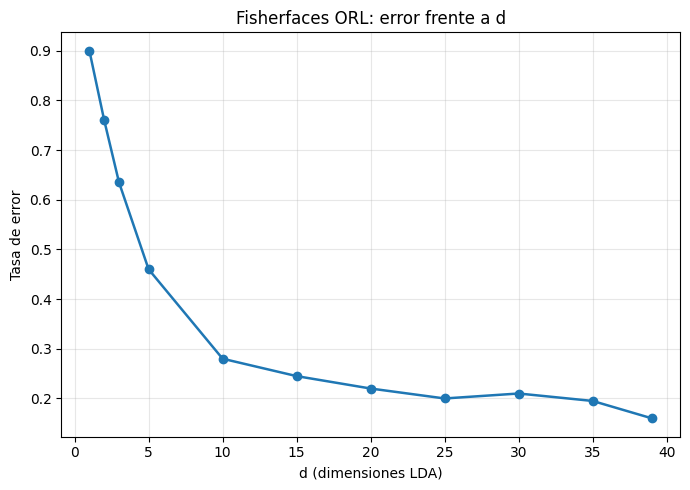

In [14]:
fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(fisher_results_df["d"], fisher_results_df["tasa_error"], marker="o", linewidth=1.8)
ax.set_xlabel("d (dimensiones LDA)")
ax.set_ylabel("Tasa de error")
ax.set_title("Fisherfaces ORL: error frente a d")
ax.grid(True, alpha=0.3)
fig.tight_layout()

fisher_curve_path = FISHER_OUT / "curva_error_orl.png"
fig.savefig(fisher_curve_path, dpi=150)
fisher_curve_path


Aunque LDA es supervisado, en este experimento Fisherfaces queda por debajo del mejor resultado de Eigenfaces. Puede ser que sea debido a que sólo hay 5 imágenes de entrenamiento por persona, por lo que estimar bien la variabilidad intra-clase es difícil. Además, el resultado depende de la dimensión PCA previa y de la regularización usada en `Sw`.


### Cara media y primeras fisherfaces


(PosixPath('/home/odra/GitHub/ComputerVisionLab/biometria/outputs/fisherfaces_orl/cara_media.png'),
 PosixPath('/home/odra/GitHub/ComputerVisionLab/biometria/outputs/fisherfaces_orl/primeras_fisherfaces.png'))

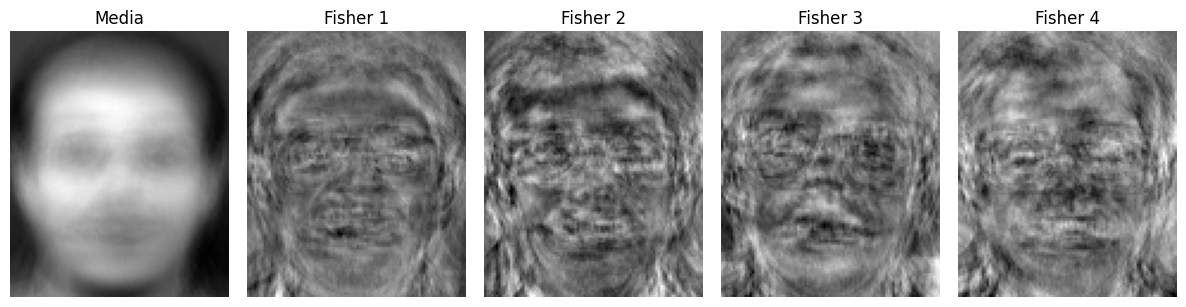

In [15]:
fisher_mean_path = FISHER_OUT / "cara_media.png"
fisher_grid_path = FISHER_OUT / "primeras_fisherfaces.png"
fisher.save_mean_face(mean_face_f, image_shape_f, fisher_mean_path)
fisher.save_fisherfaces_visualization(W_pca, V_lda, image_shape_f, fisher_grid_path, num_faces=16)

fisherfaces_img = W_pca @ V_lda
fig, axes = plt.subplots(1, 5, figsize=(12, 3))
axes[0].imshow(fisher.to_uint8_visualization(mean_face_f.reshape(image_shape_f)), cmap="gray", vmin=0, vmax=255)
axes[0].set_title("Media")
for i, ax in enumerate(axes[1:], start=1):
    ax.imshow(fisher.to_uint8_visualization(fisherfaces_img[:, i - 1].reshape(image_shape_f)), cmap="gray", vmin=0, vmax=255)
    ax.set_title(f"Fisher {i}")
for ax in axes:
    ax.axis("off")
fig.tight_layout()

fisher_mean_path, fisher_grid_path



### Errores con la mejor dimensión

Igual que en Eigenfaces, reviso los fallos en el valor de `d` con menor error para ver qué sujetos concentran las confusiones.


In [16]:
fisher_pred_best = fisher_pred_df[fisher_pred_df["d"] == best_fisher_d].copy().reset_index(drop=True)

fisher_por_persona = (
    fisher_pred_best.groupby("persona_real", as_index=False)
    .agg(test=("correcta", "count"), accuracy=("correcta", "mean"), errores=("correcta", lambda s: int((~s).sum())))
    .sort_values(["accuracy", "errores"], ascending=[True, False])
)
fisher_por_persona["accuracy"] = fisher_por_persona["accuracy"].round(3)

display(fisher_por_persona.head(10))
display(fisher_pred_best.loc[~fisher_pred_best["correcta"], ["imagen", "persona_real", "persona_predicha", "distance"]].head(10))


,persona_real,test,accuracy,errores
13,14,5,0.0,5
26,27,5,0.2,4
15,16,5,0.4,3
16,17,5,0.4,3
27,28,5,0.6,2
31,32,5,0.6,2
35,36,5,0.6,2
38,39,5,0.6,2
3,4,5,0.8,1
6,7,5,0.8,1


,imagen,persona_real,persona_predicha,distance
15,Test/s4/6.pgm,4,25,4.447065
32,Test/s7/8.pgm,7,23,5.504846
52,Test/s11/8.pgm,11,15,6.171688
65,Test/s14/6.pgm,14,21,5.657584
66,Test/s14/7.pgm,14,21,5.808121
67,Test/s14/8.pgm,14,21,5.700627
68,Test/s14/9.pgm,14,21,6.119700
69,Test/s14/10.pgm,14,22,5.318114
76,Test/s16/7.pgm,16,1,5.226854
77,Test/s16/8.pgm,16,1,5.121510


Los errores también se concentran en algunos sujetos concretos. Por ejemplo, una persona aparece con todas sus imágenes de test mal clasificadas. Esto indica que, para esas clases, la proyección LDA aprendida no consigue separarlas bien de otras personas. Por tanto, el resultado no sólo depende del método, sino también de la cantidad de datos de entrenamiento y de la variabilidad de cada sujeto.